In [5]:
import pandas as pd
import sqlite3 as sql
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [6]:
conn = sql.connect("ecommerce_hackathon.db")

def sql_query(q):
    return pd.read_sql_query(q, conn)


# Task A: Database Inspection and Cleaning 

In [7]:
 sql_query("select * from sqlite_master")

,type,name,tbl_name,rootpage,sql
0,table,customers,customers,2,"CREATE TABLE ""customers"" (\n""customer_id"" INTE..."
1,table,products,products,206,"CREATE TABLE ""products"" (\n""product_id"" INTEGE..."
2,table,orders,orders,223,"CREATE TABLE ""orders"" (\n""order_id"" INTEGER,\n..."
3,table,reviews,reviews,1263,"CREATE TABLE ""reviews"" (\n""review_id"" INTEGER,..."
4,index,idx_orders_customer,orders,1937,CREATE INDEX idx_orders_customer ON orders(cus...
5,index,idx_orders_product,orders,2105,CREATE INDEX idx_orders_product ON orders(prod...
6,index,idx_orders_date,orders,2271,CREATE INDEX idx_orders_date ON orders(order_d...
7,index,idx_reviews_customer,reviews,2568,CREATE INDEX idx_reviews_customer ON reviews(c...
8,index,idx_reviews_product,reviews,2633,CREATE INDEX idx_reviews_product ON reviews(pr...


### Show the shape and columns of each table.

In [8]:
q = """select * from customers 

"""
sql_query(q)

,customer_id,customer_name,age,gender,city,signup_date,membership_type,email,phone
0,1,Hassan Khan,20.00,Male,Karachi,2026-02-27,Standard,hassan.khan1@example.com,+92-3241-4744854
1,2,Maham Raza,33.00,Female,Rawalpindi,2025-10-17,Silver,maham.raza2@example.com,+92-3421-8078673
2,3,Ahmed Khan,25.00,Male,Karachi,2022-07-11,Standard,ahmed.khan3@example.com,+92-3139-9478454
3,4,Salman Khan,26.00,Male,Lahore,2025-02-23,Standard,salman.khan4@example.com,+92-3193-8038374
4,5,Noor Awan,27.00,Female,Lahore,2025-04-21,Standard,noor.awan5@example.com,+92-3210-3678638
...,...,...,...,...,...,...,...,...,...
7995,7996,Hassan Javed,44.00,Male,Lahore,2022-02-02,Standard,hassan.javed7996@example.com,+92-3060-7758111
7996,7997,Adeel Saeed,19.00,Male,Lahore,2022-01-24,Standard,adeel.saeed7997@example.com,+92-3141-8103048
7997,7998,Hussain Saeed,31.00,Male,Sargodha,2022-04-30,Standard,hussain.saeed7998@example.com,+92-3086-4725910
7998,7999,Anum Javed,34.00,Female,Sialkot,2025-11-20,Standard,anum.javed7999@example.com,+92-3492-7129798


In [9]:
q = """select * from products

"""
sql_query(q)

,product_id,product_name,category,brand,unit_price,stock_quantity
0,1,Readings Exam Guide Premium,Books & Stationery,Readings,566.45,103
1,2,Samsung Webcam Classic,Electronics,Samsung,"10,567.23",138
2,3,CA Sports Water Bottle Classic,Sports & Fitness,CA Sports,"6,665.04",63
3,4,LU Spice Mix Classic,Groceries,LU,516.49,113
4,5,L'Oreal Shampoo 2026,Beauty,L'Oreal,"2,581.35",107
...,...,...,...,...,...,...
995,996,Khaadi Jacket Standard,Fashion,Khaadi,779.25,126
996,997,L'Oreal Body Lotion 2026,Beauty,L'Oreal,405.86,122
997,998,Shan Detergent Mini,Groceries,Shan,362.19,136
998,999,Rivaj Sunscreen 2026,Beauty,Rivaj,"1,161.14",111


In [10]:
q = """select * from orders

"""
sql_query(q)

,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,payment_method,delivery_days,returned
0,1,2367,389,2026-04-30,1,398.27,0.11,Cash on Delivery,1.00,0
1,2,2038,927,2026-02-09,2,"44,488.20",0.08,Debit/Credit Card,1.00,0
2,3,6285,909,2026-03-30,1,"4,719.91",0.12,Cash on Delivery,1.00,0
3,4,3714,117,2026-03-24,1,"2,053.64",0.12,Easypaisa,4.00,0
4,5,3021,733,2024-12-13,1,"31,378.77",0.09,Debit/Credit Card,2.00,0
...,...,...,...,...,...,...,...,...,...,...
64995,64996,6245,849,2026-08-21,4,"3,576.73",0.05,Debit/Credit Card,2.00,0
64996,64997,3661,407,2026-08-27,1,"3,891.86",0.06,Cash on Delivery,2.00,0
64997,64998,4387,445,2026-08-28,2,"5,843.64",0.16,Debit/Credit Card,5.00,0
64998,64999,5684,102,2026-06-10,2,"35,106.59",0.07,Debit/Credit Card,3.00,0


In [11]:
q = """select * from reviews

"""
sql_query(q)

,review_id,customer_id,product_id,review_date,rating,review_text
0,1,7210,787,2026-07-28,4,"I would buy this again, item feels durable. Re..."
1,2,5566,765,2026-05-16,5,"Very satisfied, seller description was accurat..."
2,3,6106,743,2025-10-21,4,"Very satisfied, quality feels premium. Good va..."
3,4,2735,90,2026-03-25,4,"Product arrived in great condition, quality fe..."
4,5,2124,197,2026-02-23,4,"Good experience overall, packing was neat. Wil..."
...,...,...,...,...,...,...
25995,25996,2197,151,2024-05-31,4,"Good experience overall, customer support was ..."
25996,25997,5844,838,2026-08-31,5,"Quality is better than expected, price was rea..."
25997,25998,63,664,2024-11-12,4,"Good experience overall, quality feels premium..."
25998,25999,4723,278,2026-06-14,3,"It does the job, quality matches the price. No..."


Shape of Tables: (Rows,Columns)<p>
Orders : (65000,10) <p>
Customers : (8000,9)<p>
Reviews : (26000,6)<p>
Products : (1000,6)

In [12]:
customers = pd.read_sql_query("SELECT * FROM customers", conn)
products  = pd.read_sql_query("SELECT * FROM products", conn)
orders    = pd.read_sql_query("SELECT * FROM orders", conn)
reviews   = pd.read_sql_query("SELECT * FROM reviews", conn)

In [13]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      8000 non-null   int64  
 1   customer_name    8000 non-null   object 
 2   age              7900 non-null   float64
 3   gender           8000 non-null   object 
 4   city             8000 non-null   object 
 5   signup_date      8000 non-null   object 
 6   membership_type  8000 non-null   object 
 7   email            8000 non-null   object 
 8   phone            8000 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 562.6+ KB


In [14]:
customers['age'] = customers['age'].fillna(customers['age'].median())
customers['signup_date'] = pd.to_datetime(customers['signup_date'], errors='coerce')
customers['membership_type'] = customers['membership_type'].astype(str).str.strip().str.title()
customers['gender'] = customers['gender'].astype(str).str.strip().str.title()
customers['city'] = customers['city'].astype(str).str.strip().str.title()
customers['customer_name']=customers['customer_name'].astype(str)

In [15]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      8000 non-null   int64         
 1   customer_name    8000 non-null   object        
 2   age              8000 non-null   float64       
 3   gender           8000 non-null   object        
 4   city             8000 non-null   object        
 5   signup_date      8000 non-null   datetime64[ns]
 6   membership_type  8000 non-null   object        
 7   email            8000 non-null   object        
 8   phone            8000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 562.6+ KB


In [16]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26000 entries, 0 to 25999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    26000 non-null  int64 
 1   customer_id  26000 non-null  int64 
 2   product_id   26000 non-null  int64 
 3   review_date  26000 non-null  object
 4   rating       26000 non-null  int64 
 5   review_text  25952 non-null  object
dtypes: int64(4), object(2)
memory usage: 1.2+ MB


In [17]:
reviews['review_text'] = reviews['review_text'].fillna('').astype(str).str.strip()
reviews['review_date'] = pd.to_datetime(reviews['review_date'], errors='coerce')
reviews = reviews[(reviews['rating'] >= 1) & (reviews['rating'] <= 5)].copy()

In [18]:
reviews.dropna(inplace=True)

In [19]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25959 entries, 0 to 25999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   review_id    25959 non-null  int64         
 1   customer_id  25959 non-null  int64         
 2   product_id   25959 non-null  int64         
 3   review_date  25959 non-null  datetime64[ns]
 4   rating       25959 non-null  int64         
 5   review_text  25959 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 1.4+ MB


In [20]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      1000 non-null   int64  
 1   product_name    1000 non-null   object 
 2   category        1000 non-null   object 
 3   brand           980 non-null    object 
 4   unit_price      1000 non-null   float64
 5   stock_quantity  1000 non-null   int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 47.0+ KB


In [21]:
products['brand'] = products['brand'].fillna('Unknown').astype(str).str.strip().str.title()
products['category'] = products['category'].astype(str).str.strip().str.title()
products['unit_price'] = products['unit_price'].abs()
products['stock_quantity'] = products['stock_quantity'].abs()
products.dropna(inplace =True)

In [22]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      1000 non-null   int64  
 1   product_name    1000 non-null   object 
 2   category        1000 non-null   object 
 3   brand           1000 non-null   object 
 4   unit_price      1000 non-null   float64
 5   stock_quantity  1000 non-null   int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 47.0+ KB


In [23]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65000 entries, 0 to 64999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        65000 non-null  int64  
 1   customer_id     65000 non-null  int64  
 2   product_id      65000 non-null  int64  
 3   order_date      65000 non-null  object 
 4   quantity        65000 non-null  int64  
 5   unit_price      65000 non-null  float64
 6   discount        65000 non-null  float64
 7   payment_method  64945 non-null  object 
 8   delivery_days   64960 non-null  float64
 9   returned        65000 non-null  int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 5.0+ MB


In [24]:
orders['delivery_days'] = orders['delivery_days'].fillna(orders['delivery_days'].median())
orders['payment_method'] = orders['payment_method'].fillna(orders['payment_method'].mode()[0])
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
orders['quantity'] = orders['quantity'].apply(lambda x: np.nan if x <= 0 else x)
orders['unit_price'] = orders['unit_price'].apply(lambda x: np.nan if x <= 0 else x)
orders['discount'] = orders['discount'].apply(lambda x: 0.0 if x < 0 or x > 1 else x)
orders['returned'] = orders['returned'].fillna(0).astype(int)
orders = orders.dropna(subset=['quantity', 'unit_price', 'order_date']).copy()

In [25]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64890 entries, 0 to 64999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        64890 non-null  int64         
 1   customer_id     64890 non-null  int64         
 2   product_id      64890 non-null  int64         
 3   order_date      64890 non-null  datetime64[ns]
 4   quantity        64890 non-null  float64       
 5   unit_price      64890 non-null  float64       
 6   discount        64890 non-null  float64       
 7   payment_method  64890 non-null  object        
 8   delivery_days   64890 non-null  float64       
 9   returned        64890 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(4), object(1)
memory usage: 5.4+ MB


In [26]:
clean_conn = sql.connect('ecommerce_cleaned1.db')

customers.to_sql('customers', clean_conn, if_exists='replace', index=False)
products.to_sql('products', clean_conn, if_exists='replace', index=False)
orders.to_sql('orders', clean_conn, if_exists='replace', index=False)
reviews.to_sql('reviews', clean_conn, if_exists='replace', index=False)


25959

In [27]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      8000 non-null   int64         
 1   customer_name    8000 non-null   object        
 2   age              8000 non-null   float64       
 3   gender           8000 non-null   object        
 4   city             8000 non-null   object        
 5   signup_date      8000 non-null   datetime64[ns]
 6   membership_type  8000 non-null   object        
 7   email            8000 non-null   object        
 8   phone            8000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 562.6+ KB


# Task B SQL Business Analysis

In [57]:
sql_queries = """
-- Query 1: Total Net Revenue
SELECT
    SUM(quantity * unit_price * (1 - discount)) AS total_net_revenue
FROM orders;

-- Query 2: Top 10 Customers by Spending
SELECT
    c.customer_name,
    c.city,
    COUNT(o.order_id) AS number_of_orders,
    SUM(o.quantity * o.unit_price * (1 - o.discount)) AS total_spending
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
GROUP BY c.customer_id
ORDER BY total_spending DESC
LIMIT 10;

-- Query 3: Category-wise Revenue, Orders and Quantity Sold
SELECT
    p.category,
    SUM(o.quantity * o.unit_price * (1 - o.discount)) AS revenue,
    COUNT(o.order_id) AS order_count,
    SUM(o.quantity) AS quantity_sold
FROM orders o
JOIN products p
    ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY revenue DESC;

-- Query 4: Monthly Net Revenue Trend
SELECT
    strftime('%Y-%m', order_date) AS month,
    SUM(quantity * unit_price * (1 - discount)) AS monthly_revenue
FROM orders
GROUP BY month
ORDER BY month;

-- Query 5: Top 5 Products by Net Revenue
SELECT
    p.product_name,
    SUM(o.quantity * o.unit_price * (1 - o.discount)) AS revenue
FROM orders o
JOIN products p
    ON o.product_id = p.product_id
GROUP BY p.product_id
ORDER BY revenue DESC
LIMIT 5;
"""

with open("queries.sql", "w", encoding="utf-8") as f:
    f.write(sql_queries)

print("queries.sql created successfully!")

queries.sql created successfully!


In [58]:
with open("queries.sql", "r", encoding="utf-8") as f:
    print(f.read())


-- Query 1: Total Net Revenue
SELECT
    SUM(quantity * unit_price * (1 - discount)) AS total_net_revenue
FROM orders;

-- Query 2: Top 10 Customers by Spending
SELECT
    c.customer_name,
    c.city,
    COUNT(o.order_id) AS number_of_orders,
    SUM(o.quantity * o.unit_price * (1 - o.discount)) AS total_spending
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
GROUP BY c.customer_id
ORDER BY total_spending DESC
LIMIT 10;

-- Query 3: Category-wise Revenue, Orders and Quantity Sold
SELECT
    p.category,
    SUM(o.quantity * o.unit_price * (1 - o.discount)) AS revenue,
    COUNT(o.order_id) AS order_count,
    SUM(o.quantity) AS quantity_sold
FROM orders o
JOIN products p
    ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY revenue DESC;

-- Query 4: Monthly Net Revenue Trend
SELECT
    strftime('%Y-%m', order_date) AS month,
    SUM(quantity * unit_price * (1 - discount)) AS monthly_revenue
FROM orders
GROUP BY month
ORDER BY month;

-- Query 5: Top 5 P

Total Net Revenue


,total_net_revenue
0,"936,004,812.47"


Top 10 Customers by Spending


,customer_name,city,number_of_orders,total_spending
0,Shahzaib Abbasi,Lahore,43,"1,702,371.36"
1,Zoya Awan,Lahore,55,"1,549,581.16"
2,Imran Qureshi,Karachi,46,"1,496,760.37"
3,Ahmed Qureshi,Lahore,27,"1,452,407.09"
4,Danish Chaudhry,Sargodha,36,"1,428,329.85"
5,Kiran Farooq,Karachi,61,"1,380,922.58"
6,Sana Akhtar,Islamabad,48,"1,355,984.33"
7,Adeel Khan,Karachi,42,"1,355,685.05"
8,Laiba Iqbal,Karachi,49,"1,343,494.34"
9,Laiba Khan,Karachi,41,"1,342,356.67"


Category Analysis


,category,revenue,order_count,quantity_sold
0,Electronics,"656,230,748.14",11536,"16,154.00"
1,Home & Kitchen,"71,927,931.08",7619,"10,755.00"
2,Fashion,"62,143,663.42",12236,"17,143.00"
3,Sports & Fitness,"54,511,202.97",7063,"9,923.00"
4,Beauty,"46,911,283.69",11687,"16,244.00"
5,Baby & Kids,"28,797,727.20",3746,"5,334.00"
6,Groceries,"8,011,511.67",6081,"8,506.00"
7,Books & Stationery,"7,470,744.30",4922,"6,817.00"


Monthly Revenue Trend


,month,monthly_revenue
0,2022-03,"8,425.49"
1,2022-04,"80,746.37"
2,2022-05,"119,749.13"
3,2022-06,"212,855.49"
4,2022-07,"91,481.65"
5,2022-08,"703,060.77"
6,2022-09,"307,421.47"
7,2022-10,"479,041.08"
8,2022-11,"917,143.16"
9,2022-12,"832,183.00"


Top 5 Products by Revenue


,product_name,revenue
0,Samsung Headphones Classic,"117,201,547.74"
1,Anker Headphones Classic,"71,166,080.11"
2,Dawlance LED TV Premium,"20,773,037.84"
3,Infinix LED TV 2026,"16,279,307.97"
4,Dawlance Router Eco,"15,135,571.48"


In [29]:
valid_orders = orders[(orders['returned'] == 0) | (orders['returned'].isna())].copy()
valid_orders['net_amount'] = valid_orders['quantity'] * valid_orders['unit_price'] * (1 - valid_orders['discount'])
# ---------------------------------------------------------
# 1. Calculate Total Net Revenue
# ---------------------------------------------------------
total_net_revenue = valid_orders['net_amount'].sum()
print(f"1. Total Net Revenue: ${total_net_revenue:,.2f}\n")

# ---------------------------------------------------------
# 2. Top 10 Customers by Total Spending
# Show: customer_name, city, number of orders, total spending
# ---------------------------------------------------------
cust_orders = valid_orders.merge(customers, on='customer_id', how='inner')

top_10_customers = (
    cust_orders.groupby(['customer_id', 'customer_name', 'city'])
    .agg(
        total_orders=('order_id', 'count'),
        total_spending=('net_amount', 'sum')
    )
    .reset_index()
    .sort_values(by='total_spending', ascending=False)
    .head(10)[['customer_name', 'city', 'total_orders', 'total_spending']]
)

print("2. Top 10 Customers by Total Spending:")
print(top_10_customers.to_string(index=False), "\n")


# ---------------------------------------------------------
# 3. Category-Wise Revenue, Order Count, and Quantity Sold
# ---------------------------------------------------------
prod_orders = valid_orders.merge(products, on='product_id', how='inner')

category_summary = (
    prod_orders.groupby('category')
    .agg(
        order_count=('order_id', 'count'),
        total_quantity_sold=('quantity', 'sum'),
        category_revenue=('net_amount', 'sum')
    )
    .reset_index()
    .sort_values(by='category_revenue', ascending=False)
)

print("3. Category-Wise Performance:")
print(category_summary.to_string(index=False), "\n")


1. Total Net Revenue: $865,169,922.03

2. Top 10 Customers by Total Spending:
  customer_name       city  total_orders  total_spending
Shahzaib Abbasi     Lahore            37    1,537,800.62
      Zoya Awan     Lahore            50    1,515,401.07
  Ahmed Qureshi     Lahore            27    1,452,407.09
   Kiran Farooq    Karachi            57    1,353,157.41
     Laiba Khan    Karachi            40    1,340,945.41
     Adeel Khan    Karachi            38    1,333,846.74
     Fahad Khan  Islamabad            51    1,252,693.65
     Bilal Awan    Karachi            45    1,248,563.98
  Imran Qureshi    Karachi            44    1,247,069.53
    Danish Awan Faisalabad            43    1,240,877.18 

3. Category-Wise Performance:
          category  order_count  total_quantity_sold  category_revenue
       Electronics        10615            14,861.00    604,463,146.49
    Home & Kitchen         7117            10,047.00     67,176,614.34
           Fashion        10859            15,221.

In [30]:

# ---------------------------------------------------------
# 4. Monthly Net Revenue Trend
# ---------------------------------------------------------
valid_orders['order_month'] = valid_orders['order_date'].dt.to_period('M')

monthly_revenue = (
    valid_orders.groupby('order_month')
    .agg(monthly_net_revenue=('net_amount', 'sum'))
    .reset_index()
    .sort_values(by='order_month')
)
monthly_revenue['order_month'] = monthly_revenue['order_month'].astype(str)

print("4. Monthly Net Revenue Trend:")
print(monthly_revenue.to_string(index=False), "\n")



4. Monthly Net Revenue Trend:
order_month  monthly_net_revenue
    2022-03             8,425.49
    2022-04            80,746.37
    2022-05           119,461.53
    2022-06           203,912.12
    2022-07            89,778.47
    2022-08           698,996.03
    2022-09           293,353.07
    2022-10           361,749.29
    2022-11           895,729.89
    2022-12           558,315.69
    2023-01         1,153,621.67
    2023-02         1,095,209.81
    2023-03         1,845,093.02
    2023-04         1,253,117.91
    2023-05         2,030,305.99
    2023-06         2,419,487.25
    2023-07         2,973,025.66
    2023-08         3,114,630.53
    2023-09         3,326,551.26
    2023-10         3,178,648.84
    2023-11         3,905,640.95
    2023-12         4,265,617.89
    2024-01         4,426,147.23
    2024-02         5,397,107.24
    2024-03         7,109,369.21
    2024-04         7,539,464.36
    2024-05         7,986,381.96
    2024-06         7,235,733.66
    2024-07  

In [31]:
import plotly.express as px

fig = px.line(
    monthly_revenue, 
    x='order_month', 
    y='monthly_net_revenue',
    title='Monthly Net Revenue Trend',
    markers=True,
    labels={'order_month': 'Month', 'monthly_net_revenue': 'Net Revenue ($)'}
)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [32]:

# ---------------------------------------------------------
# 5. Top 5 Products by Net Revenue
# ---------------------------------------------------------
top_5_products = (
    prod_orders.groupby(['product_id', 'product_name', 'category'])
    .agg(net_revenue=('net_amount', 'sum'))
    .reset_index()
    .sort_values(by='net_revenue', ascending=False)
    .head(5)
)

print("5. Top 5 Products by Net Revenue:")
print(top_5_products.to_string(index=False))

5. Top 5 Products by Net Revenue:
 product_id               product_name    category    net_revenue
        765 Samsung Headphones Classic Electronics 105,698,173.53
        233   Anker Headphones Classic Electronics  66,013,975.20
        961    Dawlance LED TV Premium Electronics  19,030,700.98
        406        Infinix LED TV 2026 Electronics  15,654,003.13
         59        Dawlance Router Eco Electronics  14,176,597.19


# Task C: Exploratory Data Analysis 

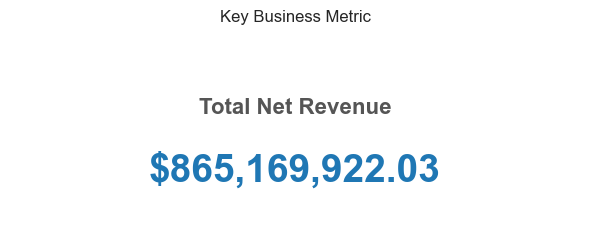

In [33]:

# Set clean aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

# ---------------------------------------------------------
# 1. Total Net Revenue (KPI Display Card)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.axis('off')
ax.text(0.5, 0.6, "Total Net Revenue", fontsize=16, ha='center', color='#555555', fontweight='bold')
ax.text(0.5, 0.25, f"${total_net_revenue:,.2f}", fontsize=28, ha='center', color='#1f77b4', fontweight='bold')
plt.title("Key Business Metric", fontsize=12, pad=10, loc='center')
plt.tight_layout()
plt.show()

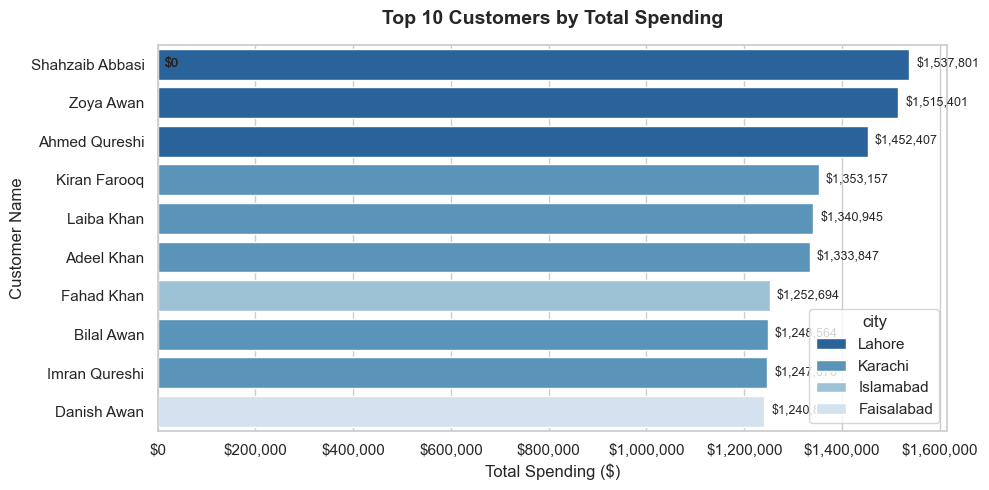

In [34]:

# ---------------------------------------------------------
# 2. Top 10 Customers by Total Spending (Horizontal Bar Chart)
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=top_10_customers,
    x='total_spending',
    y='customer_name',
    palette='Blues_r',
    hue = 'city'
)
plt.title('Top 10 Customers by Total Spending', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Spending ($)', fontsize=12)
plt.ylabel('Customer Name', fontsize=12)

# Annotate values on the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'${width:,.0f}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=9)

ax.xaxis.set_major_formatter('${x:,.0f}')
plt.tight_layout()
plt.show()


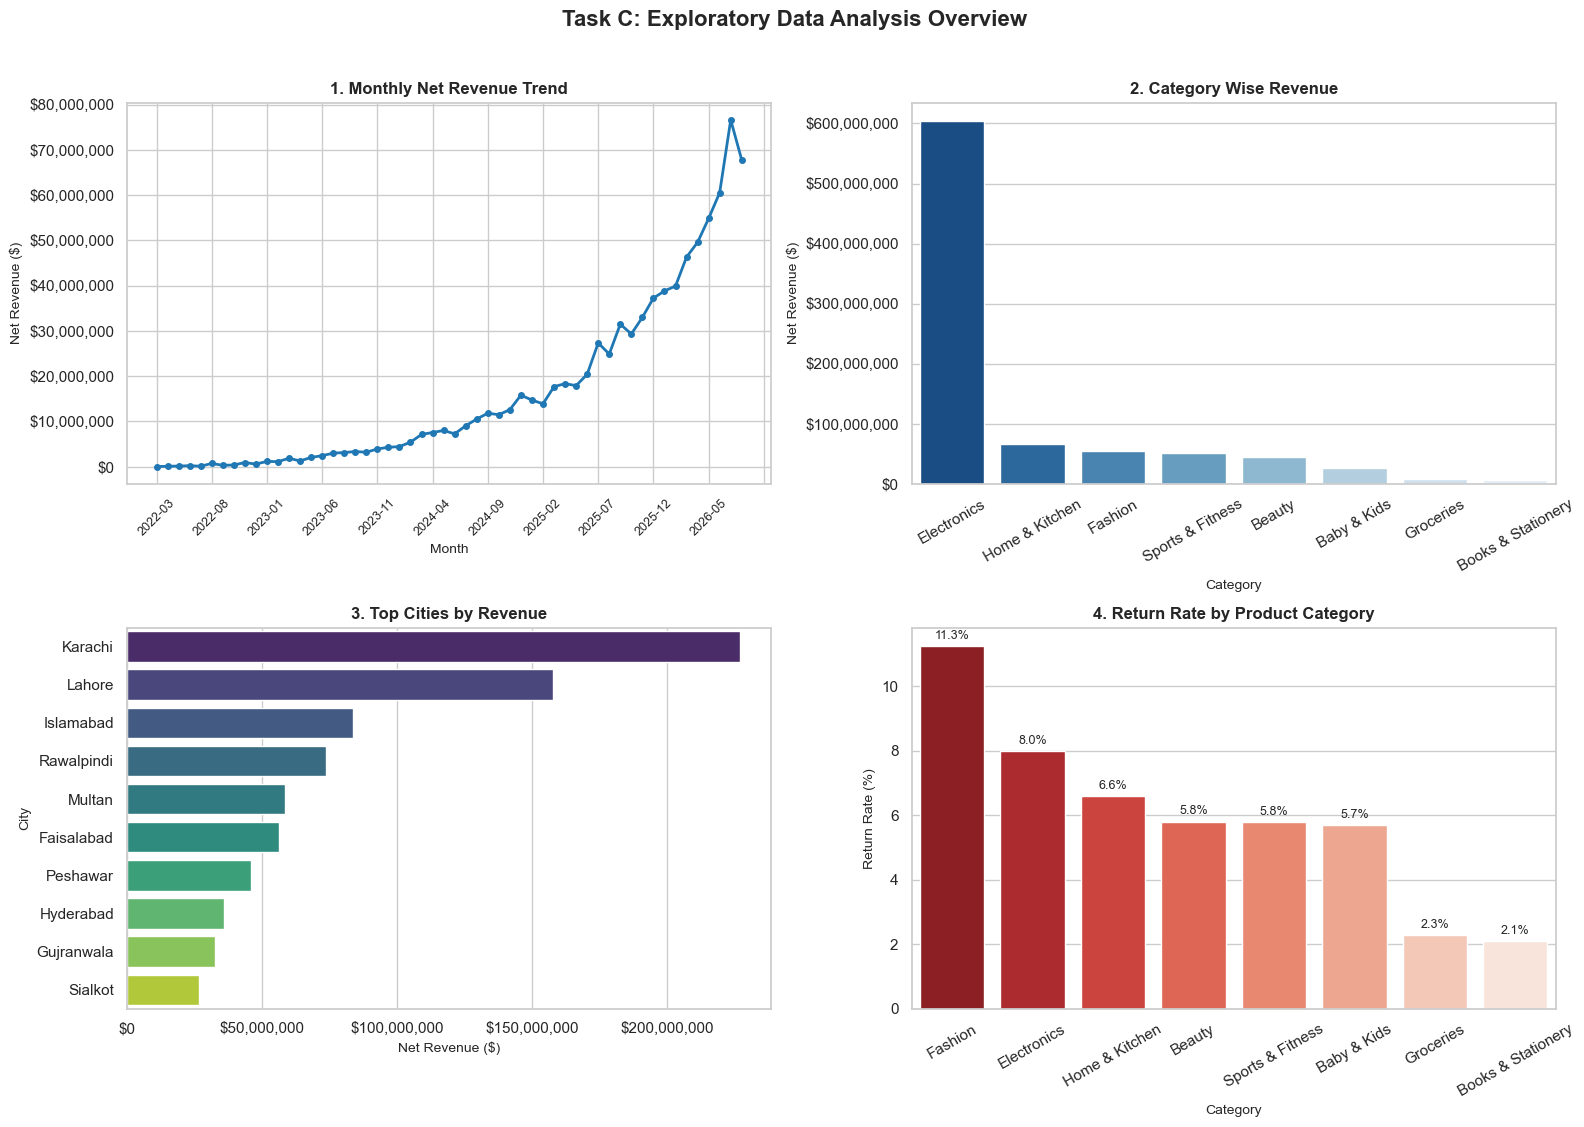

In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Set clean overall aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'figure.autolayout': True})

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ---------------------------------------------------------
# 1. Monthly Revenue Trend (Fixed X-Axis Ticks)
# ---------------------------------------------------------
valid_orders['order_month'] = valid_orders['order_date'].dt.to_period('M').astype(str)
monthly_rev = (
    valid_orders.groupby('order_month')['net_amount']
    .sum()
    .reset_index()
    .sort_values('order_month')
)

axes[0, 0].plot(
    monthly_rev['order_month'], 
    monthly_rev['net_amount'], 
    marker='o', 
    color='#1f77b4', 
    linewidth=2,
    markersize=4
)
axes[0, 0].set_title('1. Monthly Net Revenue Trend', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Month', fontsize=10)
axes[0, 0].set_ylabel('Net Revenue ($)', fontsize=10)

# FIX: Limit the number of visible x-ticks so they don't overlap
axes[0, 0].xaxis.set_major_locator(ticker.MaxNLocator(nbins=12))
axes[0, 0].tick_params(axis='x', rotation=45, labelsize=9)
axes[0, 0].yaxis.set_major_formatter('${x:,.0f}')

# ---------------------------------------------------------
# 2. Category Wise Revenue
# ---------------------------------------------------------
cat_orders = valid_orders.merge(products, on='product_id', how='inner')
category_rev = (
    cat_orders.groupby('category')['net_amount']
    .sum()
    .reset_index()
    .sort_values(by='net_amount', ascending=False)
)

sns.barplot(
    data=category_rev, 
    x='category', 
    y='net_amount', 
    hue='category',
    legend=False,
    ax=axes[0, 1], 
    palette='Blues_r'
)
axes[0, 1].set_title('2. Category Wise Revenue', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Category', fontsize=10)
axes[0, 1].set_ylabel('Net Revenue ($)', fontsize=10)
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].yaxis.set_major_formatter('${x:,.0f}')

# ---------------------------------------------------------
# 3. Top Cities by Revenue
# ---------------------------------------------------------
city_orders = valid_orders.merge(customers, on='customer_id', how='inner')
city_rev = (
    city_orders.groupby('city')['net_amount']
    .sum()
    .reset_index()
    .sort_values(by='net_amount', ascending=False)
    .head(10)
)

sns.barplot(
    data=city_rev, 
    x='net_amount', 
    y='city', 
    hue='city',
    legend=False,
    ax=axes[1, 0], 
    palette='viridis'
)
axes[1, 0].set_title('3. Top Cities by Revenue', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Net Revenue ($)', fontsize=10)
axes[1, 0].set_ylabel('City', fontsize=10)
axes[1, 0].xaxis.set_major_formatter('${x:,.0f}')

# ---------------------------------------------------------
# 4. Return Rate by Product Category
# ---------------------------------------------------------
all_cat_orders = orders.merge(products, on='product_id', how='inner')
category_returns = (
    all_cat_orders.groupby('category')['returned']
    .mean()
    .reset_index()
    .sort_values(by='returned', ascending=False)
)
category_returns['return_pct'] = category_returns['returned'] * 100

sns.barplot(
    data=category_returns, 
    x='category', 
    y='return_pct', 
    hue='category',
    legend=False,
    ax=axes[1, 1], 
    palette='Reds_r'
)
axes[1, 1].set_title('4. Return Rate by Product Category', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Category', fontsize=10)
axes[1, 1].set_ylabel('Return Rate (%)', fontsize=10)
axes[1, 1].tick_params(axis='x', rotation=30)

for p in axes[1, 1].patches:
    height = p.get_height()
    axes[1, 1].annotate(f'{height:.1f}%',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', xytext=(0, 3),
                        textcoords='offset points', fontsize=9)

plt.suptitle("Task C: Exploratory Data Analysis Overview", fontsize=16, fontweight='bold', y=1.02)
plt.show()

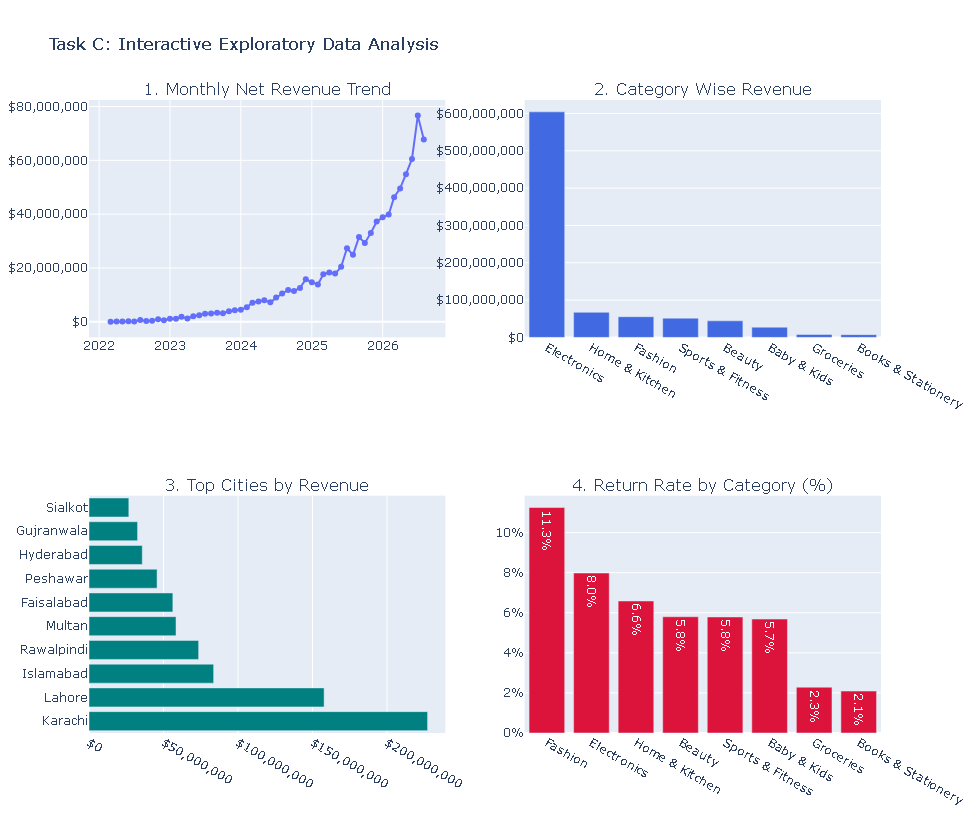

In [36]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Create 2x2 Subplots Grid
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "1. Monthly Net Revenue Trend", 
        "2. Category Wise Revenue", 
        "3. Top Cities by Revenue", 
        "4. Return Rate by Category (%)"
    )
)

# 1. Monthly Revenue Trend Line
fig.add_trace(
    go.Scatter(
        x=monthly_rev['order_month'], 
        y=monthly_rev['net_amount'],
        mode='lines+markers',
        name='Net Revenue',
        hovertemplate='Month: %{x}<br>Revenue: $%{y:,.2f}'
    ),
    row=1, col=1
)

# 2. Category Wise Revenue
fig.add_trace(
    go.Bar(
        x=category_rev['category'], 
        y=category_rev['net_amount'],
        name='Category Revenue',
        marker_color='royalblue',
        hovertemplate='Category: %{x}<br>Revenue: $%{y:,.2f}'
    ),
    row=1, col=2
)

# 3. Top Cities by Revenue (Horizontal Bar)
fig.add_trace(
    go.Bar(
        x=city_rev['net_amount'], 
        y=city_rev['city'],
        orientation='h',
        name='City Revenue',
        marker_color='teal',
        hovertemplate='City: %{y}<br>Revenue: $%{x:,.2f}'
    ),
    row=2, col=1
)

# 4. Return Rate by Category
fig.add_trace(
    go.Bar(
        x=category_returns['category'], 
        y=category_returns['return_pct'],
        name='Return Rate',
        marker_color='crimson',
        text=[f"{val:.1f}%" for val in category_returns['return_pct']],
        textposition='auto',
        hovertemplate='Category: %{x}<br>Return Rate: %{y:.2f}%'
    ),
    row=2, col=2
)

# Format Axes and Layout
fig.update_layout(
    height=800, 
    width=1100, 
    title_text="Task C: Interactive Exploratory Data Analysis",
    showlegend=False
)

# Format currency tick labels
fig.update_yaxes(tickprefix="$", tickformat=",.0f", row=1, col=1)
fig.update_yaxes(tickprefix="$", tickformat=",.0f", row=1, col=2)
fig.update_xaxes(tickprefix="$", tickformat=",.0f", row=2, col=1)
fig.update_yaxes(ticksuffix="%", row=2, col=2)

fig.show()

# Task D Machine Learning: Customer Churn 

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, 
confusion_matrix, classification_report, roc_curve)

In [38]:
# ---------------------------------------------------------
# 1. FEATURE ENGINEERING & TARGET CREATION
# ---------------------------------------------------------
# Ensure date columns are converted to datetime
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Define cutoff and target dates
cutoff_date = pd.to_datetime('2026-05-31')
target_start = pd.to_datetime('2026-06-01')
target_end = pd.to_datetime('2026-08-31')

# Filter orders up to cutoff date (for feature extraction)
feature_orders = orders[orders['order_date'] <= cutoff_date].copy()

# Calculate net amount per order
feature_orders['net_amount'] = (
    feature_orders['quantity'] * feature_orders['unit_price'] * (1 - feature_orders['discount'])
)

# Identify active customers up to cutoff date
active_customers = feature_orders['customer_id'].unique()

# Feature Aggregation per customer
features = (
    feature_orders.groupby('customer_id')
    .agg(
        total_orders=('order_id', 'count'),
        total_spending=('net_amount', 'sum'),
        avg_order_value=('net_amount', 'mean'),
        last_order_date=('order_date', 'max'),
        return_rate=('returned', 'mean'),
        avg_delivery_days=('delivery_days', 'mean')
    )
    .reset_index()
)

# Calculate days since last order as of 31 May 2026
features['days_since_last_order'] = (cutoff_date - features['last_order_date']).dt.days
features.drop(columns=['last_order_date'], inplace=True)

# Merge demographic features (Age, Membership Type) from customers DataFrame
customer_features = features.merge(
    customers[['customer_id', 'age', 'membership_type']], 
    on='customer_id', 
    how='inner'
)

# Determine Target (Churn during 1 June 2026 - 31 August 2026)
target_orders = orders[
    (orders['order_date'] >= target_start) & (orders['order_date'] <= target_end)
]
target_active_customers = set(target_orders['customer_id'].unique())

# Churn = 1 if no purchase in target window, else 0
customer_features['churn'] = customer_features['customer_id'].apply(
    lambda x: 0 if x in target_active_customers else 1
)

# Fill missing return rates if any
customer_features['return_rate'] = customer_features['return_rate'].fillna(0)

# ---------------------------------------------------------
# 2. MODEL PREPARATION & PREPROCESSING PIPELINE
# ---------------------------------------------------------
X = customer_features[[
    'total_orders', 'total_spending', 'avg_order_value', 
    'days_since_last_order', 'return_rate', 'avg_delivery_days', 
    'age', 'membership_type'
]]
y = customer_features['churn']

# Define numerical and categorical feature columns
num_cols = [
    'total_orders', 'total_spending', 'avg_order_value', 
    'days_since_last_order', 'return_rate', 'avg_delivery_days', 'age'
]
cat_cols = ['membership_type']

# Column Transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

# ---------------------------------------------------------
# 3. MODEL TRAINING & EVALUATION
# ---------------------------------------------------------
# Build Pipelines
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Fit Models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Evaluation Helper Function
def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_probs)
    cm = confusion_matrix(y_test, y_pred)
    
    return {
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc,
        'Confusion Matrix': cm
    }

# Collect Results
lr_results = evaluate_model(lr_pipeline, 'Logistic Regression', X_test, y_test)
rf_results = evaluate_model(rf_pipeline, 'Random Forest', X_test, y_test)

# Display Comparison
results_df = pd.DataFrame([lr_results, rf_results]).drop(columns=['Confusion Matrix'])
print("--- Model Performance Comparison ---")
print(results_df.to_string(index=False), "\n")

print("--- Confusion Matrices ---")
print("Logistic Regression Matrix:")
print(lr_results['Confusion Matrix'])
print("\nRandom Forest Matrix:")
print(rf_results['Confusion Matrix'])

--- Model Performance Comparison ---
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression      0.72       0.67    0.84      0.74     0.79
      Random Forest      0.70       0.68    0.76      0.71     0.76 

--- Confusion Matrices ---
Logistic Regression Matrix:
[[397 269]
 [103 538]]

Random Forest Matrix:
[[433 233]
 [156 485]]


In [39]:
import joblib

joblib.dump(lr_pipeline, "churn_logistic_model.pkl")

print("Logistic Regression model saved successfully!")


Logistic Regression model saved successfully!


# Task E: Deep Learning 

In [40]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# ---------------------------------------------------------
# 1. PREPARE PREPROCESSED ARRAYS
# ---------------------------------------------------------
# Transform train and test features using the existing ColumnTransformer
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

input_dim = X_train_trans.shape[1]

# ---------------------------------------------------------
# 2. BUILD THE FEED-FORWARD NEURAL NETWORK (32 -> 16 -> 1)
# ---------------------------------------------------------
nn_model = Sequential([
    Dense(32, activation='relu', input_shape=(input_dim,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification output
])

# Compile model with Binary Cross-Entropy Loss and Adam Optimizer
nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the Neural Network
history = nn_model.fit(
    X_train_trans, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# ---------------------------------------------------------
# 3. EVALUATE ON TEST DATA
# ---------------------------------------------------------
y_nn_probs = nn_model.predict(X_test_trans, verbose=0).ravel()
y_nn_pred = (y_nn_probs >= 0.5).astype(int)

# Metrics
nn_acc = accuracy_score(y_test, y_nn_pred)
nn_prec = precision_score(y_test, y_nn_pred)
nn_rec = recall_score(y_test, y_nn_pred)
nn_f1 = f1_score(y_test, y_nn_pred)
nn_auc = roc_auc_score(y_test, y_nn_probs)
nn_cm = confusion_matrix(y_test, y_nn_pred)

# ---------------------------------------------------------
# 4. THREE-MODEL COMPARISON TABLE
# ---------------------------------------------------------
all_results = pd.DataFrame([
    {
        'Model': 'Logistic Regression', 
        'Accuracy': lr_results['Accuracy'], 
        'Precision': lr_results['Precision'], 
        'Recall': lr_results['Recall'], 
        'F1-Score': lr_results['F1-Score'], 
        'ROC-AUC': lr_results['ROC-AUC']
    },
    {
        'Model': 'Random Forest', 
        'Accuracy': rf_results['Accuracy'], 
        'Precision': rf_results['Precision'], 
        'Recall': rf_results['Recall'], 
        'F1-Score': rf_results['F1-Score'], 
        'ROC-AUC': rf_results['ROC-AUC']
    },
    {
        'Model': 'Neural Network (32->16->1)', 
        'Accuracy': nn_acc, 
        'Precision': nn_prec, 
        'Recall': nn_rec, 
        'F1-Score': nn_f1, 
        'ROC-AUC': nn_auc
    }
])

print("--- Overall Model Performance Comparison ---")
print(all_results.to_string(index=False), "\n")

print("--- Neural Network Confusion Matrix ---")
print(nn_cm)

--- Overall Model Performance Comparison ---
                     Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
       Logistic Regression      0.72       0.67    0.84      0.74     0.79
             Random Forest      0.70       0.68    0.76      0.71     0.76
Neural Network (32->16->1)      0.70       0.68    0.71      0.70     0.77 

--- Neural Network Confusion Matrix ---
[[452 214]
 [183 458]]


In [41]:
nn_model.save("deep_learning_model.keras")

print("Deep Learning model saved successfully!")

Deep Learning model saved successfully!


In [42]:
X_train_trans = preprocessor.fit_transform(X_train)

In [43]:
import joblib

joblib.dump(preprocessor, "dl_preprocessor.pkl")

print("Preprocessor saved successfully!")


Preprocessor saved successfully!


# Task F: NLP Sentiment Analysis

In [83]:
import sqlite3
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import joblib

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# --- 1. Data Cleaning & Sentiment Mapping ---
reviews = reviews.dropna(subset=['review_text', 'rating'])
reviews = reviews[reviews['review_text'].astype(str).str.strip() != '']

def create_sentiment(rating):
    if rating in [1, 2]:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

reviews['sentiment'] = reviews['rating'].apply(create_sentiment)

# --- 2. Simplified Preprocessing ---
lemmatizer = WordNetLemmatizer()

# Keep negation words in stopwords so TF-IDF bigrams can pick up 'not good', 'not bad'
stop_words = set(stopwords.words('english')) - {"not", "no", "never", "nor", "neither"}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    tokens = word_tokenize(text)
    processed = [
        lemmatizer.lemmatize(word) 
        for word in tokens 
        if word not in stop_words and len(word) > 1
    ]
    return " ".join(processed)

reviews['clean_text'] = reviews['review_text'].apply(clean_text)

# --- 3. Vectorization & Model Training ---
X = reviews['clean_text']
y = reviews['sentiment']

# TF-IDF handles 1-grams and 2-grams naturally (e.g. "terrible product", "not good")
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

sentiment_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    C=1.0
)

sentiment_model.fit(X_train, y_train)

y_pred = sentiment_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Accuracy :", round(acc,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

print(classification_report(y_test, y_pred))


[nltk_data] Downloading package punkt to C:\Users\msreh/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\msreh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\msreh/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       401
     Neutral       1.00      1.00      1.00      1091
    Positive       1.00      1.00      1.00      3682

    accuracy                           1.00      5174
   macro avg       1.00      1.00      1.00      5174
weighted avg       1.00      1.00      1.00      5174



In [85]:
joblib.dump(
    sentiment_model,
    "sentiment_model.pkl")

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

['tfidf_vectorizer.pkl']

In [86]:
loaded_model = joblib.load(
    "sentiment_model.pkl"
)

loaded_vectorizer= joblib.load(
    "tfidf_vectorizer.pkl"
)

sample = ["this product is not amazing"]

sample_clean = clean_text(sample[0])

sample_vector = loaded_vectorizer.transform(
    [sample_clean]
)

prediction = loaded_model.predict(
    sample_vector
)

print(prediction[0])

Negative


In [87]:
test_reviews = [
    "not good",
    "not amazing",
    "terrible product",
    "worst purchase ever",
    "excellent product",
    "very good quality"
]

for review in test_reviews:
    cleaned = clean_text(review)
    vector = tfidf.transform([cleaned])
    pred = sentiment_model.predict(vector)[0]

    print(f"Review: {review}")
    print(f"Cleaned: {cleaned}")
    print(f"Prediction: {pred}")
    print("-"*50)

Review: not good
Cleaned: not good
Prediction: Negative
--------------------------------------------------
Review: not amazing
Cleaned: not amazing
Prediction: Negative
--------------------------------------------------
Review: terrible product
Cleaned: terrible product
Prediction: Positive
--------------------------------------------------
Review: worst purchase ever
Cleaned: worst purchase ever
Prediction: Negative
--------------------------------------------------
Review: excellent product
Cleaned: excellent product
Prediction: Positive
--------------------------------------------------
Review: very good quality
Cleaned: good quality
Prediction: Positive
--------------------------------------------------


In [88]:

# --- 4. Prediction Function for Testing Custom Inputs ---
def predict_review(text):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    pred = sentiment_model.predict(vec)[0]
    print(f"Review: {text}")
    print(f"Cleaned: {cleaned}")
    print(f"Prediction: {pred}\n" + "-"*40)

# Test cases
predict_review("not good")
predict_review("terrible product")
predict_review("worst purchase ever")
predict_review("excellent product")

Review: not good
Cleaned: not good
Prediction: Negative
----------------------------------------
Review: terrible product
Cleaned: terrible product
Prediction: Positive
----------------------------------------
Review: worst purchase ever
Cleaned: worst purchase ever
Prediction: Negative
----------------------------------------
Review: excellent product
Cleaned: excellent product
Prediction: Positive
----------------------------------------


In [91]:
customer_features.to_csv(
"customer_features.csv",
index=False
)